# Diagonal spectral spike detector — tolerant version

2100–2400 nm帯で、隣接波長より単発的に大きいスペクトル値を持つピクセルを検出します。

ポイント:
- スペクトル方向の局所ピーク `I_i - (I_{i-1}+I_{i+1})/2` を使う
- robust z-scoreで各波長の異常度を標準化する
- `y=x` と平行な線は `y - x = const.` として扱う
- 実際の線が1px幅とは限らないので、`|(y-x)-d| <= DIAG_HALF_WIDTH` の帯として検出する

In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path(r"D:\research\code\all_roi_spectra200x200.csv")
OUT_DIR = Path(r"D:\research\code\diagonal_spike_tolerant_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

WL_MIN = 2100.0
WL_MAX = 2400.0
PIXEL_Z_THRESHOLD = 4.0
DIAG_HALF_WIDTH = 2
MIN_CENTER_LINE_LENGTH = 80
MIN_HIT_FRACTION = 0.20
MIN_MEAN_Z = 1.0

In [3]:
def parse_wavelengths(columns):
    wave_cols = []
    wavelengths = []
    for c in columns:
        m = re.fullmatch(r'wave_([0-9]+(?:\.[0-9]+)?)nm', str(c))
        if m is not None:
            wave_cols.append(c)
            wavelengths.append(float(m.group(1)))
    return wave_cols, np.asarray(wavelengths, dtype=float)

def robust_zscore_per_band(spike):
    med = np.nanmedian(spike, axis=(0, 1))
    mad = np.nanmedian(np.abs(spike - med), axis=(0, 1))
    return (spike - med) / (1.4826 * (mad + 1e-12))

def load_cube(csv_path):
    df = pd.read_csv(csv_path)
    wave_cols, wavelengths = parse_wavelengths(df.columns)
    df = df.sort_values(['y', 'x']).reset_index(drop=True)
    height = int(df['y'].max()) + 1
    width = int(df['x'].max()) + 1
    cube = df[wave_cols].to_numpy(dtype=np.float32).reshape(height, width, len(wave_cols))
    return cube, wavelengths, df

def compute_spectral_spike(cube, wavelengths):
    spike = cube[:, :, 1:-1] - 0.5 * (cube[:, :, :-2] + cube[:, :, 2:])
    spike_wavelengths = wavelengths[1:-1]
    return spike, spike_wavelengths

In [6]:
cube, wavelengths, df = load_cube(CSV_PATH)
spike, spike_wavelengths = compute_spectral_spike(cube, wavelengths)

wl_mask = (spike_wavelengths >= WL_MIN) & (spike_wavelengths <= WL_MAX)
spike_band = spike[:, :, wl_mask]
spike_wavelengths_band = spike_wavelengths[wl_mask]
spike_z = robust_zscore_per_band(spike_band)

print(cube.shape)
print(spike_wavelengths_band[0], spike_wavelengths_band[-1], len(spike_wavelengths_band))

(200, 200, 185)
2100.05 2399.82 25


In [7]:
height, width, _ = spike_z.shape
yy, xx = np.indices((height, width))
diag = yy - xx

rows = []
for d in range(-(width - 1), height):
    center_len = int((diag == d).sum())
    if center_len < MIN_CENTER_LINE_LENGTH:
        continue

    band_mask = np.abs(diag - d) <= DIAG_HALF_WIDTH
    vals = spike_z[band_mask, :]
    hit_fraction = (vals > PIXEL_Z_THRESHOLD).mean(axis=0)
    mean_z = vals.mean(axis=0)
    median_z = np.median(vals, axis=0)
    p90_z = np.percentile(vals, 90, axis=0)
    max_z = vals.max(axis=0)

    for i, wl in enumerate(spike_wavelengths_band):
        if hit_fraction[i] >= MIN_HIT_FRACTION and mean_z[i] >= MIN_MEAN_Z:
            rows.append({
                'diag_center_d_y_minus_x': d,
                'wavelength_nm': wl,
                'center_line_length_px': center_len,
                'diagonal_band_half_width_px': DIAG_HALF_WIDTH,
                'diagonal_band_n_px': int(vals.shape[0]),
                'hit_fraction': float(hit_fraction[i]),
                'mean_z': float(mean_z[i]),
                'median_z': float(median_z[i]),
                'p90_z': float(p90_z[i]),
                'max_z': float(max_z[i]),
            })

detected = pd.DataFrame(rows).sort_values(['hit_fraction', 'mean_z'], ascending=False).reset_index(drop=True)
detected.to_csv(OUT_DIR / 'tolerant_detected_diagonal_lines.csv', index=False)
detected

,diag_center_d_y_minus_x,wavelength_nm,center_line_length_px,diagonal_band_half_width_px,diagonal_band_n_px,hit_fraction,mean_z,median_z,p90_z,max_z
0,-22,2174.99,178,2,890,0.517978,85.665825,18.099449,256.888214,382.898438
1,-21,2174.99,179,2,895,0.493855,80.649239,2.135977,254.853424,382.898438
2,-23,2174.99,177,2,885,0.442938,70.625809,1.124174,244.173660,368.508850
3,-20,2174.99,180,2,900,0.385556,60.716763,1.011786,228.097748,382.898438
4,52,2387.32,148,2,740,0.345946,2.847103,1.391135,8.945442,11.972227
5,53,2387.32,147,2,735,0.318367,2.669056,1.096043,8.987598,11.972227
6,-24,2174.99,176,2,880,0.311364,49.439259,0.224875,218.811935,368.508850
7,51,2387.32,149,2,745,0.304698,2.499464,0.927423,8.852706,11.972227
8,-19,2174.99,181,2,905,0.247514,39.264214,0.562087,184.704010,382.898438
9,54,2387.32,146,2,730,0.241096,1.941816,0.590178,7.360390,11.719288


## `y-x=50` 付近の確認

ユーザーが気にしている `y=50,x=0` から `y=199,x=149` 付近は `y-x=50` です。ただし実データでは `y-x=51〜54` にまたがって強く出ています。

In [8]:
target_wl = 2387.32
wi = int(np.argmin(np.abs(spike_wavelengths_band - target_wl)))
print('nearest wavelength:', spike_wavelengths_band[wi])

summary_rows = []
for d in range(45, 61):
    vals = spike_z[:, :, wi][diag == d]
    summary_rows.append({
        'd_y_minus_x': d,
        'line_length': len(vals),
        'frac_z_gt_3': float((vals > 3).mean()),
        'frac_z_gt_4': float((vals > 4).mean()),
        'mean_z': float(vals.mean()),
        'median_z': float(np.median(vals)),
        'p90_z': float(np.percentile(vals, 90)),
        'max_z': float(vals.max()),
    })

pd.DataFrame(summary_rows)

nearest wavelength: 2387.32


,d_y_minus_x,line_length,frac_z_gt_3,frac_z_gt_4,mean_z,median_z,p90_z,max_z
0,45,155,0.000000,0.000000,-0.211055,0.000000,1.011734,2.107785
1,46,154,0.000000,0.000000,-0.266079,-0.042163,1.180354,1.601914
2,47,153,0.000000,0.000000,-0.270021,-0.168632,1.163495,2.445024
3,48,152,0.000000,0.000000,-0.199689,-0.000006,1.256237,2.192092
4,49,151,0.006623,0.000000,-0.181470,-0.084319,1.180356,3.035212
5,50,150,0.193333,0.146667,0.799268,0.168613,5.412793,8.093896
6,51,149,0.469799,0.389262,3.513917,2.192092,10.454615,11.972227
7,52,148,0.648649,0.554054,4.455972,4.890064,9.189944,11.634982
8,53,147,0.510204,0.442177,3.990166,3.119521,10.033068,11.719288
9,54,146,0.280822,0.198630,1.488728,0.505868,5.986117,9.274264


WindowsPath('D:/research/code/diagonal_spike_tolerant_output/spike_z_map_2387.32nm_diag_overlay.png')

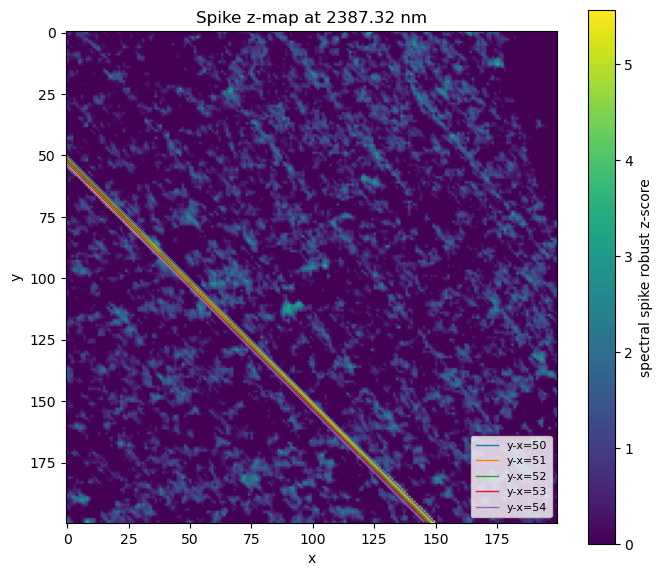

In [9]:
zmap = spike_z[:, :, wi]
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(zmap, origin='upper', vmin=0, vmax=np.nanpercentile(zmap, 99.5))
fig.colorbar(im, ax=ax, label='spectral spike robust z-score')
ax.set_title(f'Spike z-map at {spike_wavelengths_band[wi]:.2f} nm')
ax.set_xlabel('x')
ax.set_ylabel('y')
xs = np.arange(width)
for d in [50, 51, 52, 53, 54]:
    ys = xs + d
    ok = (ys >= 0) & (ys < height)
    ax.plot(xs[ok], ys[ok], linewidth=1, label=f'y-x={d}')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
plot_path = OUT_DIR / f'spike_z_map_{spike_wavelengths_band[wi]:.2f}nm_diag_overlay.png'
fig.savefig(plot_path, dpi=200)
plot_path

In [10]:
# Pixel-level list for the detected diagonal bands
pixel_rows = []
for _, line in detected.iterrows():
    d = int(line['diag_center_d_y_minus_x'])
    half = int(line['diagonal_band_half_width_px'])
    wl = float(line['wavelength_nm'])
    wi = int(np.argmin(np.abs(spike_wavelengths_band - wl)))
    mask = (np.abs(diag - d) <= half) & (spike_z[:, :, wi] > PIXEL_Z_THRESHOLD)
    ys, xs = np.where(mask)
    for y, x in zip(ys, xs):
        pixel_rows.append({
            'y': int(y),
            'x': int(x),
            'diag_d_y_minus_x': int(y - x),
            'diag_center_d_y_minus_x': d,
            'wavelength_nm': wl,
            'spike_z': float(spike_z[y, x, wi]),
        })

pixels = pd.DataFrame(pixel_rows).sort_values(['wavelength_nm', 'diag_center_d_y_minus_x', 'y', 'x']).reset_index(drop=True)
pixels.to_csv(OUT_DIR / 'tolerant_detected_anomaly_pixels.csv', index=False)
pixels.head()

,y,x,diag_d_y_minus_x,diag_center_d_y_minus_x,wavelength_nm,spike_z
0,39,61,-22,-24,2174.99,7.644475
1,40,62,-22,-24,2174.99,12.028831
2,41,63,-22,-24,2174.99,18.099449
3,42,64,-22,-24,2174.99,23.945227
4,43,65,-22,-24,2174.99,30.915176


,wavelength_nm,d_min,d_max,d_representative,n_detected_centers,hit_fraction_max,mean_z_max,diag_half_width
0,2174.99,-24,-19,-22,6,0.517978,85.665825,2
1,2387.32,50,54,52,5,0.345946,2.847103,2


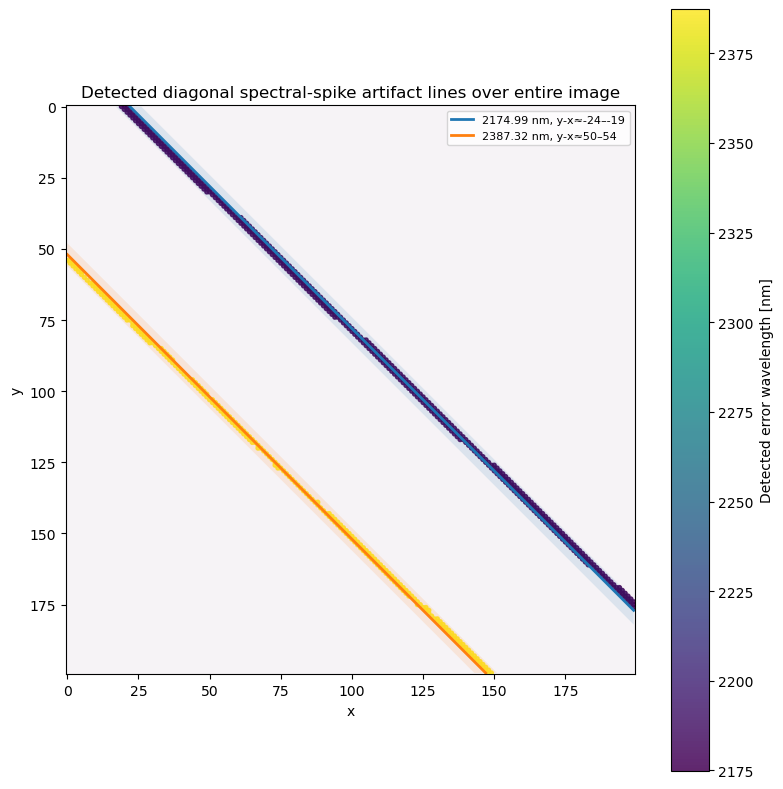

Saved: D:\research\code\diagonal_spike_tolerant_output\all_detected_diagonal_artifact_lines.png


In [11]:
# ============================================================
# 画像全体に、検出された全てのエラーピクセル直線を表示
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# もし notebook 上に detected / pixels が残っていない場合はCSVから読む
if "detected" not in globals():
    detected = pd.read_csv(OUT_DIR / "tolerant_detected_diagonal_lines.csv")

if "pixels" not in globals():
    pixels = pd.read_csv(OUT_DIR / "tolerant_detected_anomaly_pixels.csv")

# 画像サイズを取得
if "spike_z_band" in globals():
    height, width = spike_z_band.shape[:2]
elif "cube" in globals():
    height, width = cube.shape[:2]
else:
    height = int(pixels["y"].max()) + 1
    width = int(pixels["x"].max()) + 1


def merge_adjacent_diagonal_detections(detected_df, max_gap=1):
    """
    同じ波長で、隣り合う y-x の検出を1本の太い直線としてまとめる。
    例: d=50,51,52,53,54 を 1本の線状アーティファクトとして扱う。
    """
    if detected_df.empty:
        return pd.DataFrame()

    rows = []

    for wl, g in detected_df.sort_values(
        ["wavelength_nm", "diag_center_d_y_minus_x"]
    ).groupby("wavelength_nm"):

        g = g.sort_values("diag_center_d_y_minus_x").reset_index(drop=True)

        cluster = []
        prev_d = None

        for _, row in g.iterrows():
            d = int(row["diag_center_d_y_minus_x"])

            if prev_d is None or d - prev_d <= max_gap:
                cluster.append(row)
            else:
                cg = pd.DataFrame(cluster)
                best = cg.sort_values(
                    ["hit_fraction", "mean_z"], ascending=False
                ).iloc[0]

                rows.append({
                    "wavelength_nm": float(wl),
                    "d_min": int(cg["diag_center_d_y_minus_x"].min()),
                    "d_max": int(cg["diag_center_d_y_minus_x"].max()),
                    "d_representative": int(best["diag_center_d_y_minus_x"]),
                    "n_detected_centers": len(cg),
                    "hit_fraction_max": float(cg["hit_fraction"].max()),
                    "mean_z_max": float(cg["mean_z"].max()),
                    "diag_half_width": int(cg["diagonal_band_half_width_px"].max()),
                })

                cluster = [row]

            prev_d = d

        if cluster:
            cg = pd.DataFrame(cluster)
            best = cg.sort_values(
                ["hit_fraction", "mean_z"], ascending=False
            ).iloc[0]

            rows.append({
                "wavelength_nm": float(wl),
                "d_min": int(cg["diag_center_d_y_minus_x"].min()),
                "d_max": int(cg["diag_center_d_y_minus_x"].max()),
                "d_representative": int(best["diag_center_d_y_minus_x"]),
                "n_detected_centers": len(cg),
                "hit_fraction_max": float(cg["hit_fraction"].max()),
                "mean_z_max": float(cg["mean_z"].max()),
                "diag_half_width": int(cg["diagonal_band_half_width_px"].max()),
            })

    return pd.DataFrame(rows)


# 隣接する diagonal center をまとめる
merged_lines = merge_adjacent_diagonal_detections(detected, max_gap=1)

display(merged_lines)

# pixels は重複しやすいので、表示用に重複除去
pixels_plot = pixels.drop_duplicates(
    subset=["y", "x", "wavelength_nm"]
).copy()

fig, ax = plt.subplots(figsize=(8, 8))

# 背景は空の画像
ax.imshow(
    np.zeros((height, width)),
    origin="upper",
    vmin=0,
    vmax=1,
    alpha=0.05,
)

# エラーピクセルを散布図で表示
sc = ax.scatter(
    pixels_plot["x"],
    pixels_plot["y"],
    c=pixels_plot["wavelength_nm"],
    s=8,
    alpha=0.85,
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Detected error wavelength [nm]")

# 検出された斜め直線帯を重ね描き
xs = np.arange(width)

for _, row in merged_lines.iterrows():
    wl = row["wavelength_nm"]
    d_min = int(row["d_min"])
    d_max = int(row["d_max"])
    d_rep = int(row["d_representative"])
    half = int(row["diag_half_width"])

    # 中心線 y = x + d_rep
    ys = xs + d_rep
    ok = (ys >= 0) & (ys < height)

    ax.plot(
        xs[ok],
        ys[ok],
        linewidth=2,
        label=f"{wl:.2f} nm, y-x≈{d_min}–{d_max}",
    )

    # 太さを持った検出帯も薄く表示
    y_lower = xs + d_min - half
    y_upper = xs + d_max + half

    ok_band = (
        (y_upper >= 0)
        & (y_lower < height)
    )

    ax.fill_between(
        xs[ok_band],
        np.clip(y_lower[ok_band], 0, height - 1),
        np.clip(y_upper[ok_band], 0, height - 1),
        alpha=0.12,
    )

ax.set_xlim(-0.5, width - 0.5)
ax.set_ylim(height - 0.5, -0.5)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Detected diagonal spectral-spike artifact lines over entire image")

ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()

save_path = OUT_DIR / "all_detected_diagonal_artifact_lines.png"
fig.savefig(save_path, dpi=200)
plt.show()

print(f"Saved: {save_path}")

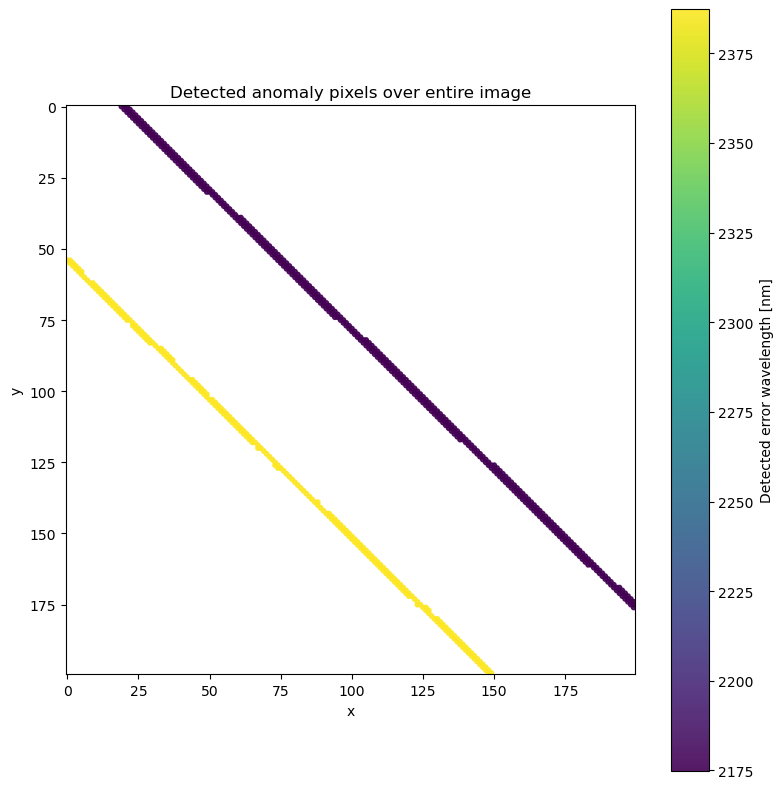

Saved: D:\research\code\diagonal_spike_tolerant_output\all_detected_anomaly_pixels.png


In [12]:
# ============================================================
# 異常ピクセルだけを画像全体に表示
# ============================================================

pixels_plot = pixels.drop_duplicates(
    subset=["y", "x", "wavelength_nm"]
).copy()

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    pixels_plot["x"],
    pixels_plot["y"],
    c=pixels_plot["wavelength_nm"],
    s=10,
    alpha=0.9,
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Detected error wavelength [nm]")

ax.set_xlim(-0.5, width - 0.5)
ax.set_ylim(height - 0.5, -0.5)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Detected anomaly pixels over entire image")

fig.tight_layout()

save_path = OUT_DIR / "all_detected_anomaly_pixels.png"
fig.savefig(save_path, dpi=200)
plt.show()

print(f"Saved: {save_path}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

def nearest_band_index(target_wl, wavelengths):
    wavelengths = np.asarray(wavelengths, dtype=float)
    return int(np.argmin(np.abs(wavelengths - target_wl)))

def robust_zscore_image(img2d):
    """
    2次元画像に対して robust z-score を返す
    """
    vals = img2d[np.isfinite(img2d)]
    med = np.median(vals)
    mad = np.median(np.abs(vals - med))
    if mad < 1e-12:
        return np.zeros_like(img2d, dtype=float)
    return 0.6745 * (img2d - med) / mad

def build_spike_cube(cube):
    """
    spike_cube[:,:,k] = cube[:,:,k] - 0.5*(cube[:,:,k-1] + cube[:,:,k+1])
    端の波長は NaN
    """
    h, w, b = cube.shape
    spike_cube = np.full((h, w, b), np.nan, dtype=float)
    spike_cube[:, :, 1:-1] = (
        cube[:, :, 1:-1]
        - 0.5 * (cube[:, :, :-2] + cube[:, :, 2:])
    )
    return spike_cube

def build_spike_z_cube(spike_cube):
    """
    各波長ごとに spike 画像を robust z-score 化
    """
    h, w, b = spike_cube.shape
    out = np.full_like(spike_cube, np.nan, dtype=float)
    for k in range(1, b - 1):
        out[:, :, k] = robust_zscore_image(spike_cube[:, :, k])
    return out

def merge_adjacent_diagonal_detections(detected_df, max_gap=1):
    """
    同じ波長で隣接する y-x をまとめて1本の帯として扱う
    """
    if detected_df.empty:
        return pd.DataFrame()

    rows = []

    for wl, g in detected_df.sort_values(
        ["wavelength_nm", "diag_center_d_y_minus_x"]
    ).groupby("wavelength_nm"):

        g = g.sort_values("diag_center_d_y_minus_x").reset_index(drop=True)

        cluster = []
        prev_d = None

        for _, row in g.iterrows():
            d = int(row["diag_center_d_y_minus_x"])

            if prev_d is None or d - prev_d <= max_gap:
                cluster.append(row)
            else:
                cg = pd.DataFrame(cluster)
                best = cg.sort_values(
                    ["hit_fraction", "mean_z"], ascending=False
                ).iloc[0]

                rows.append({
                    "wavelength_nm": float(wl),
                    "d_min": int(cg["diag_center_d_y_minus_x"].min()),
                    "d_max": int(cg["diag_center_d_y_minus_x"].max()),
                    "d_representative": int(best["diag_center_d_y_minus_x"]),
                    "diag_half_width": int(cg["diagonal_band_half_width_px"].max()),
                    "hit_fraction_max": float(cg["hit_fraction"].max()),
                    "mean_z_max": float(cg["mean_z"].max()),
                })

                cluster = [row]

            prev_d = d

        if cluster:
            cg = pd.DataFrame(cluster)
            best = cg.sort_values(
                ["hit_fraction", "mean_z"], ascending=False
            ).iloc[0]

            rows.append({
                "wavelength_nm": float(wl),
                "d_min": int(cg["diag_center_d_y_minus_x"].min()),
                "d_max": int(cg["diag_center_d_y_minus_x"].max()),
                "d_representative": int(best["diag_center_d_y_minus_x"]),
                "diag_half_width": int(cg["diagonal_band_half_width_px"].max()),
                "hit_fraction_max": float(cg["hit_fraction"].max()),
                "mean_z_max": float(cg["mean_z"].max()),
            })

    return pd.DataFrame(rows)

# 必要ならCSVから再読込
if "detected" not in globals():
    detected = pd.read_csv(OUT_DIR / "tolerant_detected_diagonal_lines.csv")

if "pixels" not in globals():
    pixels = pd.read_csv(OUT_DIR / "tolerant_detected_anomaly_pixels.csv")

# spike_cube, spike_z_cube がなければ作る
if "spike_cube" not in globals():
    spike_cube = build_spike_cube(cube)

if "spike_z_cube" not in globals():
    spike_z_cube = build_spike_z_cube(spike_cube)

merged_lines = merge_adjacent_diagonal_detections(detected, max_gap=1)

display(merged_lines)
print("準備完了")

,wavelength_nm,d_min,d_max,d_representative,diag_half_width,hit_fraction_max,mean_z_max
0,2174.99,-24,-19,-22,2,0.517978,85.665825
1,2387.32,50,54,52,2,0.345946,2.847103


準備完了


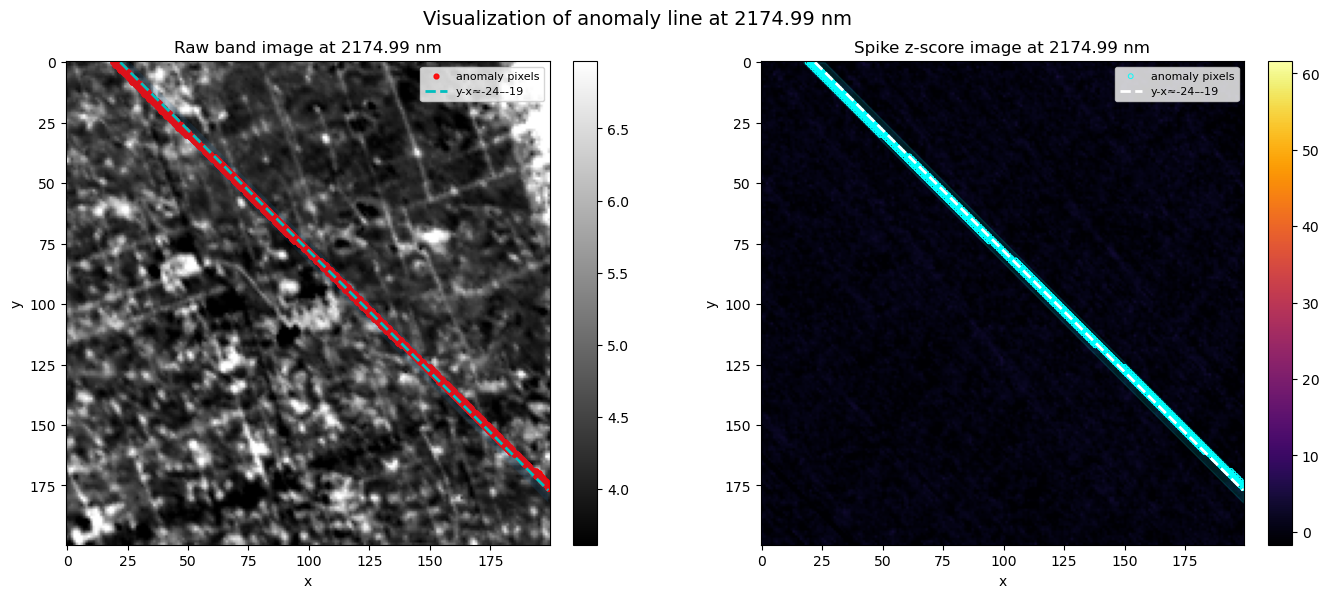

Saved: D:\research\code\diagonal_spike_tolerant_output\anomaly_line_visualization_2174.99nm.png


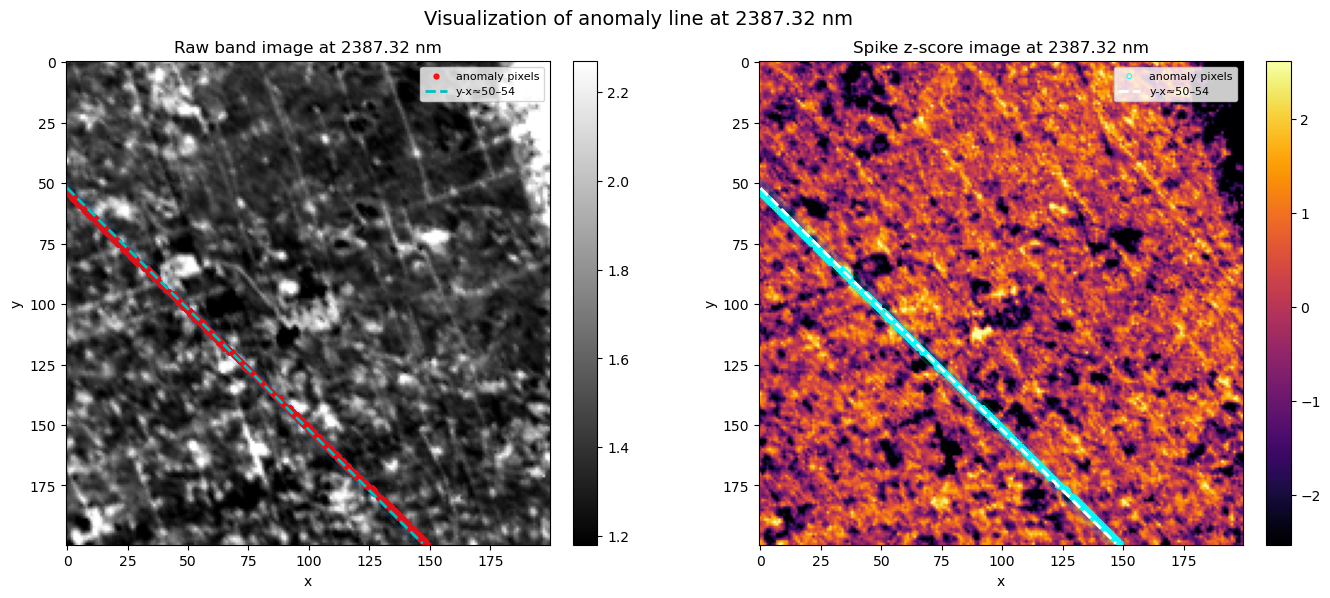

Saved: D:\research\code\diagonal_spike_tolerant_output\anomaly_line_visualization_2387.32nm.png


In [14]:
# ============================================================
# 異常波長ごとに
# 1) 元画像
# 2) spike z-score画像
# を表示し、異常ピクセルと斜め線を重ねる
# ============================================================

unique_wls = np.sort(detected["wavelength_nm"].unique())

height, width, n_bands = cube.shape

for wl in unique_wls:
    band_idx = nearest_band_index(wl, wavelengths)

    raw_img = cube[:, :, band_idx]
    z_img = spike_z_cube[:, :, band_idx]

    # この波長での異常ピクセル
    pix_wl = pixels[np.isclose(pixels["wavelength_nm"], wl, atol=0.2)].copy()

    # この波長での直線帯
    lines_wl = merged_lines[np.isclose(merged_lines["wavelength_nm"], wl, atol=0.2)].copy()

    # コントラスト調整用
    raw_vmin, raw_vmax = np.nanpercentile(raw_img, [2, 98])

    # z画像の表示範囲
    finite_z = z_img[np.isfinite(z_img)]
    if finite_z.size > 0:
        z_vmin = np.nanpercentile(finite_z, 5)
        z_vmax = np.nanpercentile(finite_z, 99)
        if z_vmax <= z_vmin:
            z_vmin, z_vmax = np.nanmin(finite_z), np.nanmax(finite_z)
    else:
        z_vmin, z_vmax = 0, 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --------------------------------------------------
    # 左: 元画像
    # --------------------------------------------------
    ax = axes[0]
    im0 = ax.imshow(
        raw_img,
        cmap="gray",
        origin="upper",
        vmin=raw_vmin,
        vmax=raw_vmax,
    )

    # 異常ピクセルを重ねる
    if len(pix_wl) > 0:
        ax.scatter(
            pix_wl["x"],
            pix_wl["y"],
            s=12,
            c="red",
            alpha=0.9,
            label="anomaly pixels"
        )

    xs = np.arange(width)

    # 斜め線帯を重ねる
    for _, row in lines_wl.iterrows():
        d_min = int(row["d_min"])
        d_max = int(row["d_max"])
        d_rep = int(row["d_representative"])
        half = int(row["diag_half_width"])

        ys = xs + d_rep
        ok = (ys >= 0) & (ys < height)

        ax.plot(
            xs[ok],
            ys[ok],
            "c--",
            linewidth=2,
            label=f"y-x≈{d_min}–{d_max}"
        )

        y_lower = xs + d_min - half
        y_upper = xs + d_max + half
        ok_band = (y_upper >= 0) & (y_lower < height)

        ax.fill_between(
            xs[ok_band],
            np.clip(y_lower[ok_band], 0, height - 1),
            np.clip(y_upper[ok_band], 0, height - 1),
            alpha=0.15,
        )

    ax.set_title(f"Raw band image at {wavelengths[band_idx]:.2f} nm")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_aspect("equal")
    fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

    # 凡例重複を消す
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)

    # --------------------------------------------------
    # 右: spike z-score画像
    # --------------------------------------------------
    ax = axes[1]
    im1 = ax.imshow(
        z_img,
        cmap="inferno",
        origin="upper",
        vmin=z_vmin,
        vmax=z_vmax,
    )

    if len(pix_wl) > 0:
        ax.scatter(
            pix_wl["x"],
            pix_wl["y"],
            s=12,
            facecolors="none",
            edgecolors="cyan",
            linewidths=0.7,
            alpha=0.95,
            label="anomaly pixels"
        )

    for _, row in lines_wl.iterrows():
        d_min = int(row["d_min"])
        d_max = int(row["d_max"])
        d_rep = int(row["d_representative"])
        half = int(row["diag_half_width"])

        ys = xs + d_rep
        ok = (ys >= 0) & (ys < height)

        ax.plot(
            xs[ok],
            ys[ok],
            "w--",
            linewidth=2,
            label=f"y-x≈{d_min}–{d_max}"
        )

        y_lower = xs + d_min - half
        y_upper = xs + d_max + half
        ok_band = (y_upper >= 0) & (y_lower < height)

        ax.fill_between(
            xs[ok_band],
            np.clip(y_lower[ok_band], 0, height - 1),
            np.clip(y_upper[ok_band], 0, height - 1),
            alpha=0.12,
            color="cyan",
        )

    ax.set_title(f"Spike z-score image at {wavelengths[band_idx]:.2f} nm")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_aspect("equal")
    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)

    fig.suptitle(f"Visualization of anomaly line at {wavelengths[band_idx]:.2f} nm", fontsize=14)
    fig.tight_layout()

    save_path = OUT_DIR / f"anomaly_line_visualization_{wavelengths[band_idx]:.2f}nm.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")

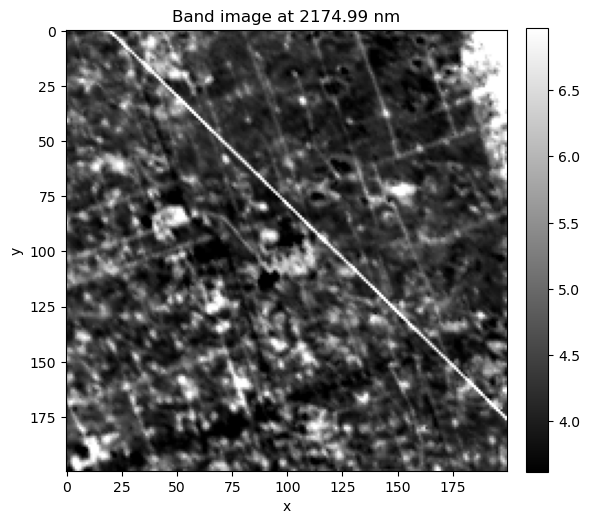

Saved: D:\research\code\diagonal_spike_tolerant_output\raw_band_2174.99nm.png


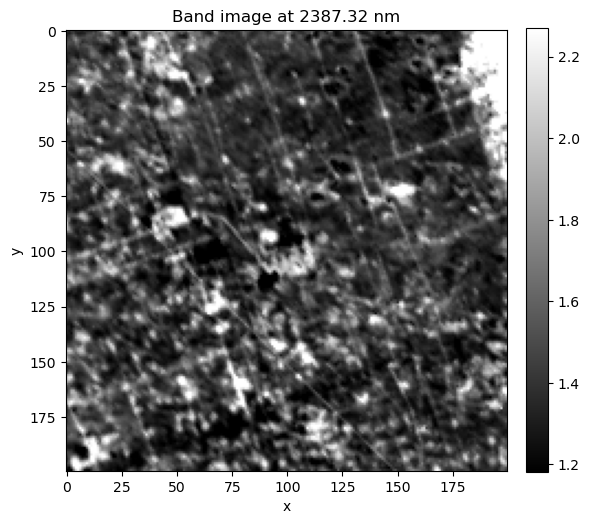

Saved: D:\research\code\diagonal_spike_tolerant_output\raw_band_2387.32nm.png


In [15]:
# ============================================================
# 検出された異常波長での画像を単純表示
# （線・異常ピクセルの重ね描きなし）
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# detected がなければ CSV から読む
if "detected" not in globals():
    detected = pd.read_csv(OUT_DIR / "tolerant_detected_diagonal_lines.csv")

def nearest_band_index(target_wl, wavelengths):
    wavelengths = np.asarray(wavelengths, dtype=float)
    return int(np.argmin(np.abs(wavelengths - target_wl)))

# 異常波長一覧
unique_wls = np.sort(detected["wavelength_nm"].unique())

height, width, n_bands = cube.shape

# 1波長ずつ表示
for wl in unique_wls:
    band_idx = nearest_band_index(wl, wavelengths)
    img = cube[:, :, band_idx]

    vmin, vmax = np.nanpercentile(img, [2, 98])

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(
        img,
        cmap="gray",
        origin="upper",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Band image at {wavelengths[band_idx]:.2f} nm")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_aspect("equal")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()

    save_path = OUT_DIR / f"raw_band_{wavelengths[band_idx]:.2f}nm.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")

表示する波長: [2125.03 2174.99 2387.32]


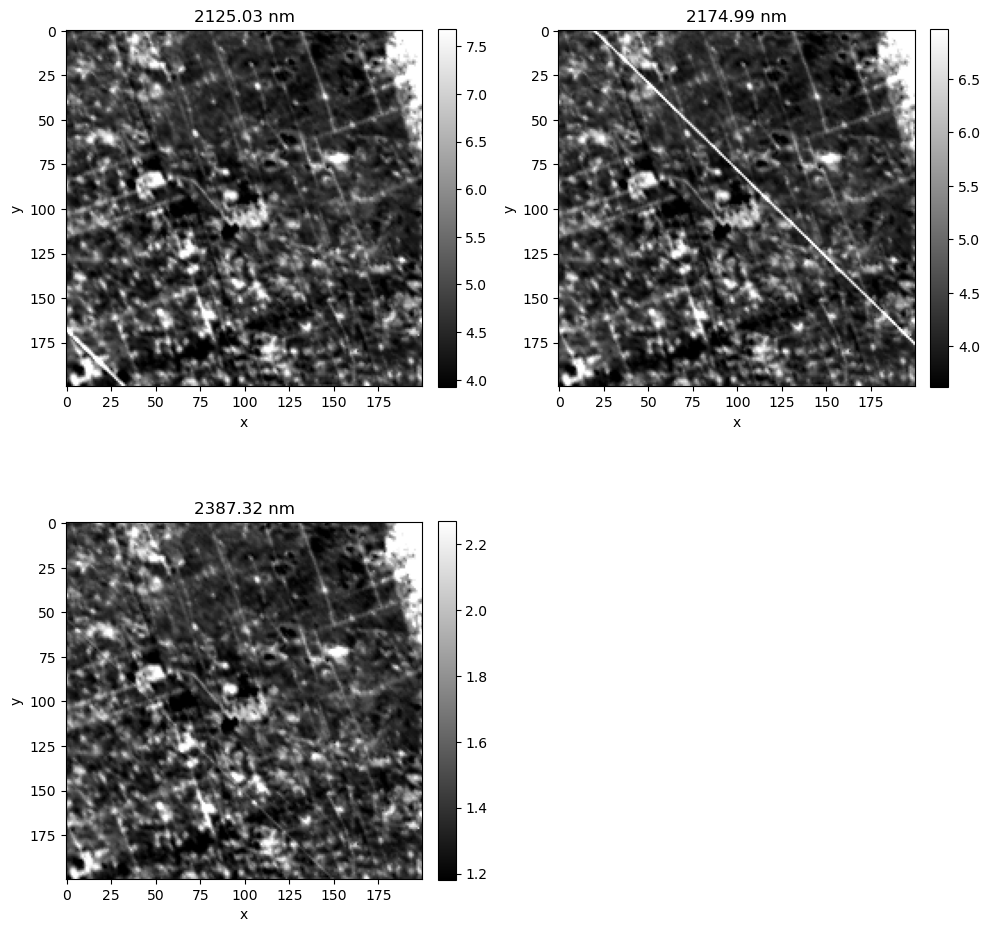

Saved: D:\research\code\diagonal_spike_tolerant_output\anomalous_wavelength_images_with_manual_2125_03nm.png


In [ ]:
# ============================================================
# 検出波長 + 手動指定波長 の画像を表示
# （線・異常ピクセルの重ね描きなし）
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# detected がなければ CSV から読む
if "detected" not in globals():
    detected = pd.read_csv(OUT_DIR / "tolerant_detected_diagonal_lines.csv")

def nearest_band_index(target_wl, wavelengths):
    wavelengths = np.asarray(wavelengths, dtype=float)
    return int(np.argmin(np.abs(wavelengths - target_wl)))

detected_wls = list(np.sort(detected["wavelength_nm"].unique()))

manual_wls = [2125.03]

display_wls = np.array(sorted(set(np.round(detected_wls + manual_wls, 2))))

print("show wavelengths:", display_wls)

height, width, n_bands = cube.shape

n = len(display_wls)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, wl in zip(axes, display_wls):
    band_idx = nearest_band_index(wl, wavelengths)
    img = cube[:, :, band_idx]

    vmin, vmax = np.nanpercentile(img, [2, 98])

    im = ax.imshow(
        img,
        cmap="gray",
        origin="upper",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"{wavelengths[band_idx]:.2f} nm")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_aspect("equal")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for k in range(len(display_wls), len(axes)):
    axes[k].axis("off")

fig.tight_layout()

save_path = OUT_DIR / "anomalous_wavelength_images_with_manual_2125_03nm.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {save_path}")

In [17]:
# ============================================================
# 2387.32 nm の異常根拠を計算で示す
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

TARGET_WL = 2387.32

# 異常線として見えていた帯
D_MIN = 50
D_MAX = 54

# 比較用の正常そうな周辺対角線
# 異常帯から少し離した y-x の範囲を使う
NORMAL_D_RANGES = [
    (35, 45),
    (59, 69),
]

Z_THRESHOLD = 4.0


def nearest_band_index(target_wl, wavelengths):
    wavelengths = np.asarray(wavelengths, dtype=float)
    return int(np.argmin(np.abs(wavelengths - target_wl)))


def robust_zscore(img):
    vals = img[np.isfinite(img)]
    med = np.nanmedian(vals)
    mad = np.nanmedian(np.abs(vals - med))
    if mad < 1e-12:
        return np.zeros_like(img, dtype=float)
    return 0.6745 * (img - med) / mad


height, width, n_bands = cube.shape

Y, X = np.indices((height, width))
D = Y - X

k = nearest_band_index(TARGET_WL, wavelengths)

wl_prev = wavelengths[k - 1]
wl_center = wavelengths[k]
wl_next = wavelengths[k + 1]

print(f"Target band index: {k}")
print(f"Previous wavelength: {wl_prev:.2f} nm")
print(f"Center wavelength:   {wl_center:.2f} nm")
print(f"Next wavelength:     {wl_next:.2f} nm")

# 局所的な持ち上がり量
# 正なら「隣接2波長の平均より高い」
# 負でも、他ピクセルより値が大きければ「通常より落ち込みが浅い」
local_deviation = (
    cube[:, :, k]
    - 0.5 * (cube[:, :, k - 1] + cube[:, :, k + 1])
)

local_z = robust_zscore(local_deviation)

# 異常線マスク
line_mask = (D >= D_MIN) & (D <= D_MAX)

# 周辺の正常そうな対角線マスク
normal_mask = np.zeros((height, width), dtype=bool)
for d0, d1 in NORMAL_D_RANGES:
    normal_mask |= (D >= d0) & (D <= d1)

# その他全体
other_mask = ~line_mask


def summarize_region(name, mask):
    prev_vals = cube[:, :, k - 1][mask]
    center_vals = cube[:, :, k][mask]
    next_vals = cube[:, :, k + 1][mask]
    dev_vals = local_deviation[mask]
    z_vals = local_z[mask]

    return {
        "region": name,
        "n_pixels": int(mask.sum()),
        f"mean_{wl_prev:.2f}nm": float(np.nanmean(prev_vals)),
        f"mean_{wl_center:.2f}nm": float(np.nanmean(center_vals)),
        f"mean_{wl_next:.2f}nm": float(np.nanmean(next_vals)),
        "mean_local_deviation": float(np.nanmean(dev_vals)),
        "median_local_deviation": float(np.nanmedian(dev_vals)),
        "mean_z": float(np.nanmean(z_vals)),
        "median_z": float(np.nanmedian(z_vals)),
        f"fraction_z_gt_{Z_THRESHOLD}": float(np.nanmean(z_vals > Z_THRESHOLD)),
        "max_z": float(np.nanmax(z_vals)),
    }


summary = pd.DataFrame([
    summarize_region(f"candidate line: y-x={D_MIN}〜{D_MAX}", line_mask),
    summarize_region("nearby normal diagonals", normal_mask),
    summarize_region("all other pixels", other_mask),
])

display(summary)

Target band index: 177
Previous wavelength: 2374.84 nm
Center wavelength:   2387.32 nm
Next wavelength:     2399.82 nm


,region,n_pixels,mean_2374.84nm,mean_2387.32nm,mean_2399.82nm,mean_local_deviation,median_local_deviation,mean_z,median_z,fraction_z_gt_4.0,max_z
0,candidate line: y-x=50〜54,740,1.711935,1.575840,1.533284,-0.046770,-0.0744,2.847142,1.391154,0.345946,11.972391
1,nearby normal diagonals,3256,1.720532,1.525197,1.542436,-0.106286,-0.1024,-0.289117,-0.084314,0.000000,3.119558
2,all other pixels,39260,1.695733,1.502851,1.518528,-0.104279,-0.1008,-0.183355,0.000000,0.000000,3.625436


In [18]:
# ============================================================
# y-x=50〜54 の帯で、どの波長が一番異常かを見る
# ============================================================

wl_rows = []

for kk in range(1, n_bands - 1):
    wl = wavelengths[kk]

    if not (2100 <= wl <= 2400):
        continue

    dev = (
        cube[:, :, kk]
        - 0.5 * (cube[:, :, kk - 1] + cube[:, :, kk + 1])
    )

    z = robust_zscore(dev)

    wl_rows.append({
        "wavelength_nm": float(wl),
        "line_mean_z": float(np.nanmean(z[line_mask])),
        "line_median_z": float(np.nanmedian(z[line_mask])),
        f"line_fraction_z_gt_{Z_THRESHOLD}": float(np.nanmean(z[line_mask] > Z_THRESHOLD)),
        "normal_mean_z": float(np.nanmean(z[normal_mask])),
        f"normal_fraction_z_gt_{Z_THRESHOLD}": float(np.nanmean(z[normal_mask] > Z_THRESHOLD)),
    })

wl_rank = pd.DataFrame(wl_rows)

wl_rank_sorted = wl_rank.sort_values(
    [f"line_fraction_z_gt_{Z_THRESHOLD}", "line_mean_z"],
    ascending=False
).reset_index(drop=True)

display(wl_rank_sorted.head(15))

,wavelength_nm,line_mean_z,line_median_z,line_fraction_z_gt_4.0,normal_mean_z,normal_fraction_z_gt_4.0
0,2387.32,2.847142,1.391154,0.345946,-0.289117,0.000000
1,2100.05,0.320109,0.061330,0.012162,0.461163,0.014435
2,2137.53,0.510926,0.269816,0.010811,0.372063,0.012592
3,2399.82,-1.089841,-0.824393,0.008108,0.318311,0.010135
4,2362.34,0.132033,0.000000,0.006757,0.263292,0.005528
5,2112.55,0.126179,0.000000,0.004054,0.341544,0.007678
6,2312.39,0.198819,0.084314,0.002703,0.152857,0.007064
7,2150.01,-0.020952,-0.168628,0.002703,0.083238,0.003686
8,2337.36,0.247921,0.168606,0.001351,0.249205,0.010442
9,2224.95,0.201229,0.168638,0.001351,0.121543,0.004914


In [19]:
# ============================================================
# 2387.32 nm において、どの y-x の直線が一番異常かを見る
# ============================================================

DIAG_HALF_WIDTH = 2

diag_rows = []

for d_center in range(-(width - 1), height):
    mask = np.abs(D - d_center) <= DIAG_HALF_WIDTH

    # 短すぎる端の対角線は除外
    if mask.sum() < 80:
        continue

    z_vals = local_z[mask]

    diag_rows.append({
        "d_center_y_minus_x": int(d_center),
        "n_pixels": int(mask.sum()),
        "mean_z": float(np.nanmean(z_vals)),
        "median_z": float(np.nanmedian(z_vals)),
        f"fraction_z_gt_{Z_THRESHOLD}": float(np.nanmean(z_vals > Z_THRESHOLD)),
        "max_z": float(np.nanmax(z_vals)),
    })

diag_rank = pd.DataFrame(diag_rows)

diag_rank_sorted = diag_rank.sort_values(
    [f"fraction_z_gt_{Z_THRESHOLD}", "mean_z"],
    ascending=False
).reset_index(drop=True)

display(diag_rank_sorted.head(20))

,d_center_y_minus_x,n_pixels,mean_z,median_z,fraction_z_gt_4.0,max_z
0,52,740,2.847142,1.391154,0.345946,11.972391
1,53,735,2.669093,1.096058,0.318367,11.972391
2,51,745,2.499498,0.927436,0.304698,11.972391
3,54,730,1.941843,0.590186,0.241096,11.719448
4,50,750,1.660280,0.421558,0.216000,11.972391
5,55,725,1.008375,0.252930,0.129655,11.719448
6,49,755,0.721064,0.084308,0.105960,11.972391
7,56,720,0.151056,0.084302,0.040278,9.274391
8,48,760,-0.026519,-0.084314,0.028947,8.094007
9,-116,420,0.516712,0.505872,0.000000,3.203872


C:\Users\yudon\AppData\Local\Temp\ipykernel_36284\2992715490.py:37: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yudon\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


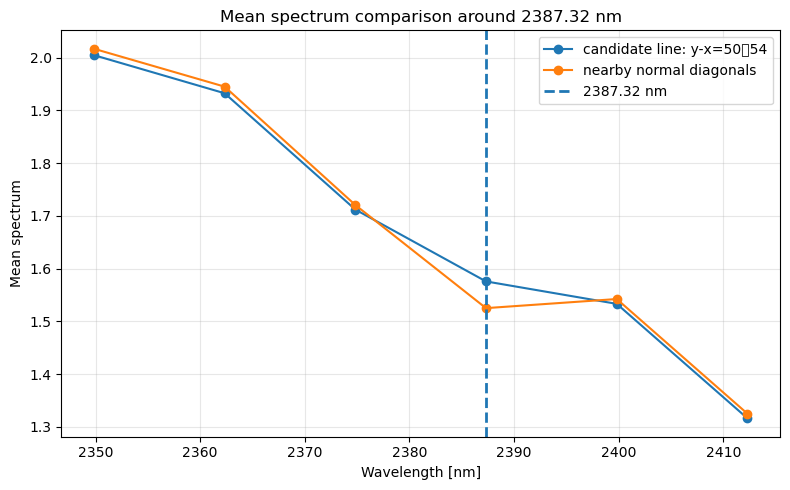

In [20]:
# ============================================================
# 平均スペクトルで 2387.32 nm の異常を示す
# ============================================================

WL_PLOT_MIN = 2340
WL_PLOT_MAX = 2420

wl_plot_mask = (wavelengths >= WL_PLOT_MIN) & (wavelengths <= WL_PLOT_MAX)

line_mean_spectrum = np.nanmean(cube[line_mask, :], axis=0)
normal_mean_spectrum = np.nanmean(cube[normal_mask, :], axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    wavelengths[wl_plot_mask],
    line_mean_spectrum[wl_plot_mask],
    marker="o",
    label=f"candidate line: y-x={D_MIN}〜{D_MAX}",
)

ax.plot(
    wavelengths[wl_plot_mask],
    normal_mean_spectrum[wl_plot_mask],
    marker="o",
    label="nearby normal diagonals",
)

ax.axvline(wl_center, linestyle="--", linewidth=2, label=f"{wl_center:.2f} nm")

ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Mean spectrum")
ax.set_title("Mean spectrum comparison around 2387.32 nm")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

C:\Users\yudon\AppData\Local\Temp\ipykernel_36284\3251386085.py:22: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


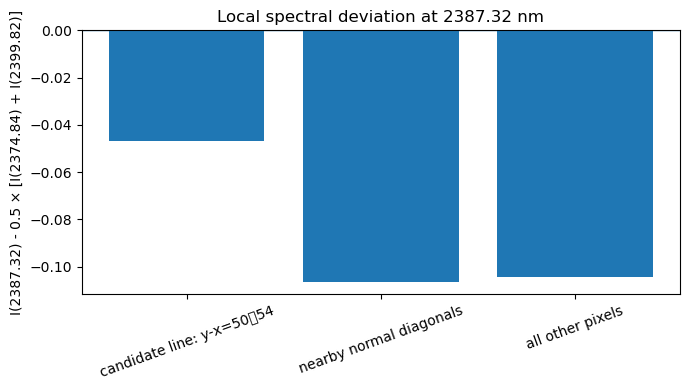

In [21]:
# ============================================================
# 2387.32 nm の local deviation を比較
# ============================================================

plot_df = summary.copy()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    plot_df["region"],
    plot_df["mean_local_deviation"],
)

ax.axhline(0, linewidth=1)

ax.set_ylabel(
    f"I({wl_center:.2f}) - 0.5 × [I({wl_prev:.2f}) + I({wl_next:.2f})]"
)
ax.set_title("Local spectral deviation at 2387.32 nm")
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()